# Simple Linear Regression — student marks prediction
### Same story as the board: dots -> line -> w, b -> predictions -> error -> best fit line

**Dataset:** `study-hours-exam-scores-data.csv` (provided separately) — 100 rows, 2 columns: `study_hours` and `exam_scores`. Add it as a Kaggle input (or upload directly if running elsewhere).

Today's formula: **ŷ = w·x + b** — x = study_hours, w = weight, b = bias, ŷ = predicted score.

In [3]:
import numpy as np
import pandas as pd

np.random.seed(42)

study_hours = np.random.uniform(1, 10, 100)
exam_score = 30 + (study_hours * 7) + np.random.normal(0, 5, 100)

df = pd.DataFrame({
    'study_hours': study_hours,
    'exam_score': exam_score
})

df.to_csv('study_hours_exam_score.csv', index=False)

print(df.head())

   study_hours  exam_score
0     4.370861   61.031263
1     9.556429   95.399965
2     7.587945   83.574422
3     6.387926   64.777640
4     2.404168   45.730815


In [4]:
import os
dataset_paths = []
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        full_path = os.path.join(dirname, filename)
        print(full_path)
        if filename.endswith('.csv'):
            dataset_paths.append(full_path)
# If nothing printed: click 'Add Input' and attach 'study-hours-exam-scores-data' first
# (or, if running outside Kaggle, just set: dataset_paths = ['study-hours-exam-scores-data.csv'])

/kaggle/input/datasets/gangabhavanidasam/study-hours-exam-scores-data/study_hours_exam_score.csv


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')

## 1. Load the data

In [6]:
assert len(dataset_paths) > 0, "No CSV found under /kaggle/input - click 'Add Input' and attach study_hours_scores_regression.csv first."
df = pd.read_csv(dataset_paths[0])
df.head()

,study_hours,exam_score
0,4.370861,61.031263
1,9.556429,95.399965
2,7.587945,83.574422
3,6.387926,64.777640
4,2.404168,45.730815


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  100 non-null    float64
 1   exam_score   100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


## 2. Data preprocessing — step by step

Even a clean dataset gets the same checks every time, so this becomes a habit.

**Preprocessing step 1 — check for missing values.**

In [8]:
df.isnull().sum()

study_hours    0
exam_score     0
dtype: int64

**Preprocessing step 2 — check for duplicate rows.**

In [9]:
print('Duplicate rows:', df.duplicated().sum())
df = df.drop_duplicates()
print('Shape after removing duplicates:', df.shape)

Duplicate rows: 0
Shape after removing duplicates: (100, 2)


**Preprocessing step 3 — sanity-check the value ranges.** No negative distances, no impossible delivery times.

In [10]:
df.describe()

,study_hours,exam_score
count,100.000000,100.000000
mean,5.231627,66.615985
std,2.677405,18.613373
min,1.049699,35.252198
25%,2.738807,51.021252
50%,5.177282,64.403856
75%,7.571828,83.145015
max,9.881982,103.082991


In [11]:
# Keep only rows with realistic values (this dataset is already clean, but we always check)
df_clean = df[(df['study_hours'] > 0) & (df['exam_score'] > 0)].copy()
print('Rows remaining after sanity check:', df_clean.shape[0])

Rows remaining after sanity check: 100


In [12]:
print(df.columns)

Index(['study_hours', 'exam_score'], dtype='object')


## 3. See the pattern — data as dots (same as the board)

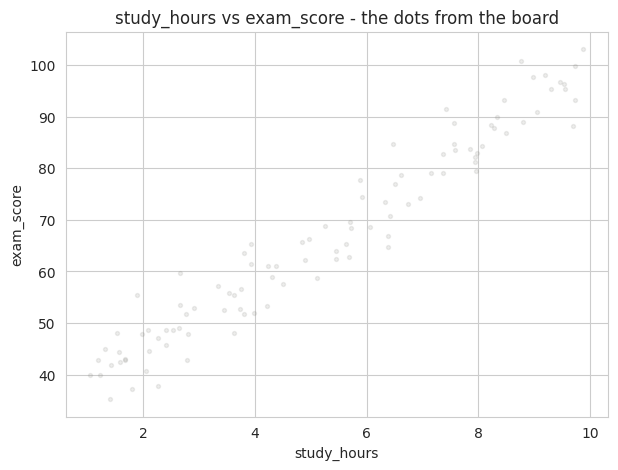

Correlation: 0.970159704333297


In [13]:
plt.figure(figsize=(7,5))
plt.scatter(df_clean['study_hours'], df_clean['exam_score'], alpha=0.15, s=8, color='#888780')
plt.xlabel('study_hours')
plt.ylabel('exam_score')
plt.title('study_hours vs exam_score - the dots from the board')
plt.show()

print('Correlation:', df_clean['study_hours'].corr(df_clean['exam_score']))

## 4. Train / test split

We hold back part of the data (the test set) that the model never sees while learning, so we can honestly check how it performs on deliveries it hasn't encountered before.

```
Full dataset
     |
  -----------
  |         |
Training   Test
(~80%)    (~20%)
  |
model learns w, b
from this part ONLY
```

In [14]:
X = df_clean[['study_hours']].values   # double brackets keep this 2D - sklearn requires a 2D feature matrix
y = df_clean['exam_score'].values

# test_size=0.2 -> 80% train, 20% test. random_state fixes the shuffle so results are reproducible.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Training rows:', X_train.shape[0], '(model learns w, b from these)')
print('Test rows:', X_test.shape[0], '(used only to check performance afterward)')

Training rows: 80 (model learns w, b from these)
Test rows: 20 (used only to check performance afterward)


## 5. Before training: w and b are unknown

Right now, nothing has been learned yet. `LinearRegression()` just creates an empty model.

In [15]:
model = LinearRegression()
print('Model created. w and b are not learned yet - training happens on the next line.')

Model created. w and b are not learned yet - training happens on the next line.


## 6. Training — `.fit()` finds the best w and b

This is the ONE line where everything from the board (best fit line, minimizing squared error) happens. scikit-learn solves for the exact best w and b directly (a method called least squares) rather than taking iterative small steps — but the goal is identical: minimize the total squared error across the training rows.

In [16]:
model.fit(X_train, y_train)   # learns from TRAINING data only

w = model.coef_[0]      # the learned weight (slope)
b = model.intercept_    # the learned bias (intercept)
print(f'Learned formula: exam_score = {w:.3f} * study_hours + {b:.3f}')
print(f'\nInterpretation: each extra hour of study adds about {w:.1f} marks to the predicted exam score.')

Learned formula: exam_score = 6.777 * study_hours + 30.938

Interpretation: each extra hour of study adds about 6.8 marks to the predicted exam score.


## 7. See the best fit line drawn over the dots

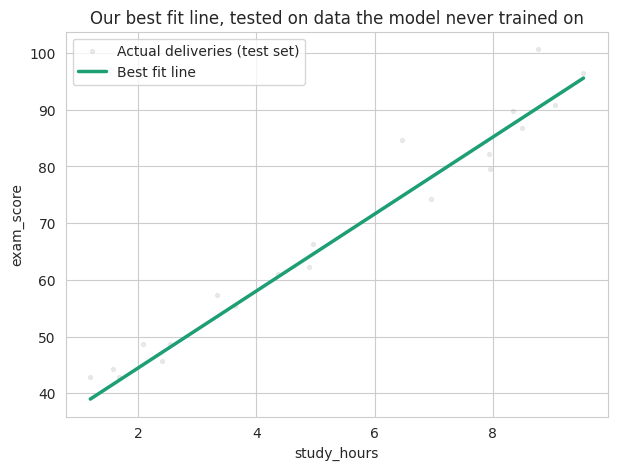

In [17]:
y_pred_test = model.predict(X_test)   # apply the learned line to the TEST distances (never seen during training)

plt.figure(figsize=(7,5))
plt.scatter(X_test, y_test, alpha=0.15, s=8, color='#888780', label='Actual deliveries (test set)')
sort_idx = X_test.flatten().argsort()
plt.plot(X_test.flatten()[sort_idx], y_pred_test[sort_idx], color='#1D9E75', linewidth=2.5, label='Best fit line')
plt.xlabel('study_hours')
plt.ylabel('exam_score')
plt.title('Our best fit line, tested on data the model never trained on')
plt.legend()
plt.show()

## 8. Low x vs high x — watch the prediction move

In [18]:
for test_hours in [1, 3, 5, 8, 12]:
    predicted_time = model.predict([[test_hours]])[0]   # predict() expects a 2D input, so [[value]]
    print(f'Hours = {test_hours} ->  Predicted score = {predicted_time:.1f} min')

Hours = 1 ->  Predicted score = 37.7 min
Hours = 3 ->  Predicted score = 51.3 min
Hours = 5 ->  Predicted score = 64.8 min
Hours = 8 ->  Predicted score = 85.2 min
Hours = 12 ->  Predicted score = 112.3 min


## 9. Metrics — measured on the TEST set only

This is the honest check: how good are the predictions on deliveries the model never trained on?

In [19]:
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

print(f'MAE:  {mae:.2f} score  -> on average, predictions are off by this many marks')
print(f'RMSE: {rmse:.2f} score -> same idea, but punishes big mistakes harder')
print(f'R2:   {r2:.3f}          -> how much better this line is than just guessing the average every time (closer to 1 = better)')

MAE:  2.96 score  -> on average, predictions are off by this many marks
RMSE: 4.04 score -> same idea, but punishes big mistakes harder
R2:   0.955          -> how much better this line is than just guessing the average every time (closer to 1 = better)


## 10. What if distance = 0?

Let's actually check what our model predicts, and see why we shouldn't blindly trust it there.

In [20]:
zero_prediction = model.predict([[0]])[0]
print(f'Model prediction at study_hours=0: {zero_prediction:.1f} marks')
print(f'\nOur training data study hours range: {df_clean["study_hours"].min():.1f} hours to {df_clean["study_hours"].max():.1f} hours')
print('0 study hours is right at (or outside) the edge of what the model actually trained on,')
print('so this number is a mathematical artifact of the line, not a fully trustworthy real-world prediction.')

Model prediction at study_hours=0: 30.9 marks

Our training data study hours range: 1.0 hours to 9.9 hours
0 study hours is right at (or outside) the edge of what the model actually trained on,
so this number is a mathematical artifact of the line, not a fully trustworthy real-world prediction.


## Recap
- Preprocessing: checked nulls, duplicates, and value ranges before modeling
- Train/test split: model learns from training rows only, tested honestly on rows it never saw
- ŷ = w·x + b, and what w and b mean physically for this dataset
- Best fit line: the line with the smallest total squared error on the training data
- `.fit()` learns w and b (least squares); `.predict()` just applies the learned equation
- MAE, RMSE, R² measured on the test set
- Why a prediction at x=0 (or outside the training range) shouldn't be fully trusted
